Import Library and Data

In [1642]:
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

In [1643]:
BTC_Ticker = "BTC-USD"
ETH_Ticker = "ETH-USD"

In [1644]:
start_date = datetime(2023, 2, 1)
end_date = datetime(2024, 2, 1)

In [1645]:
BTC_1d = yf.Ticker(BTC_Ticker).history(interval="1d", start=start_date, end=end_date)
ETH_1d = yf.Ticker(ETH_Ticker).history(interval="1d", start=start_date, end=end_date)

In [1646]:
BTC_5d = yf.Ticker(BTC_Ticker).history(interval="5d", start=start_date, end=end_date)
ETH_5d = yf.Ticker(ETH_Ticker).history(interval="5d", start=start_date, end=end_date)

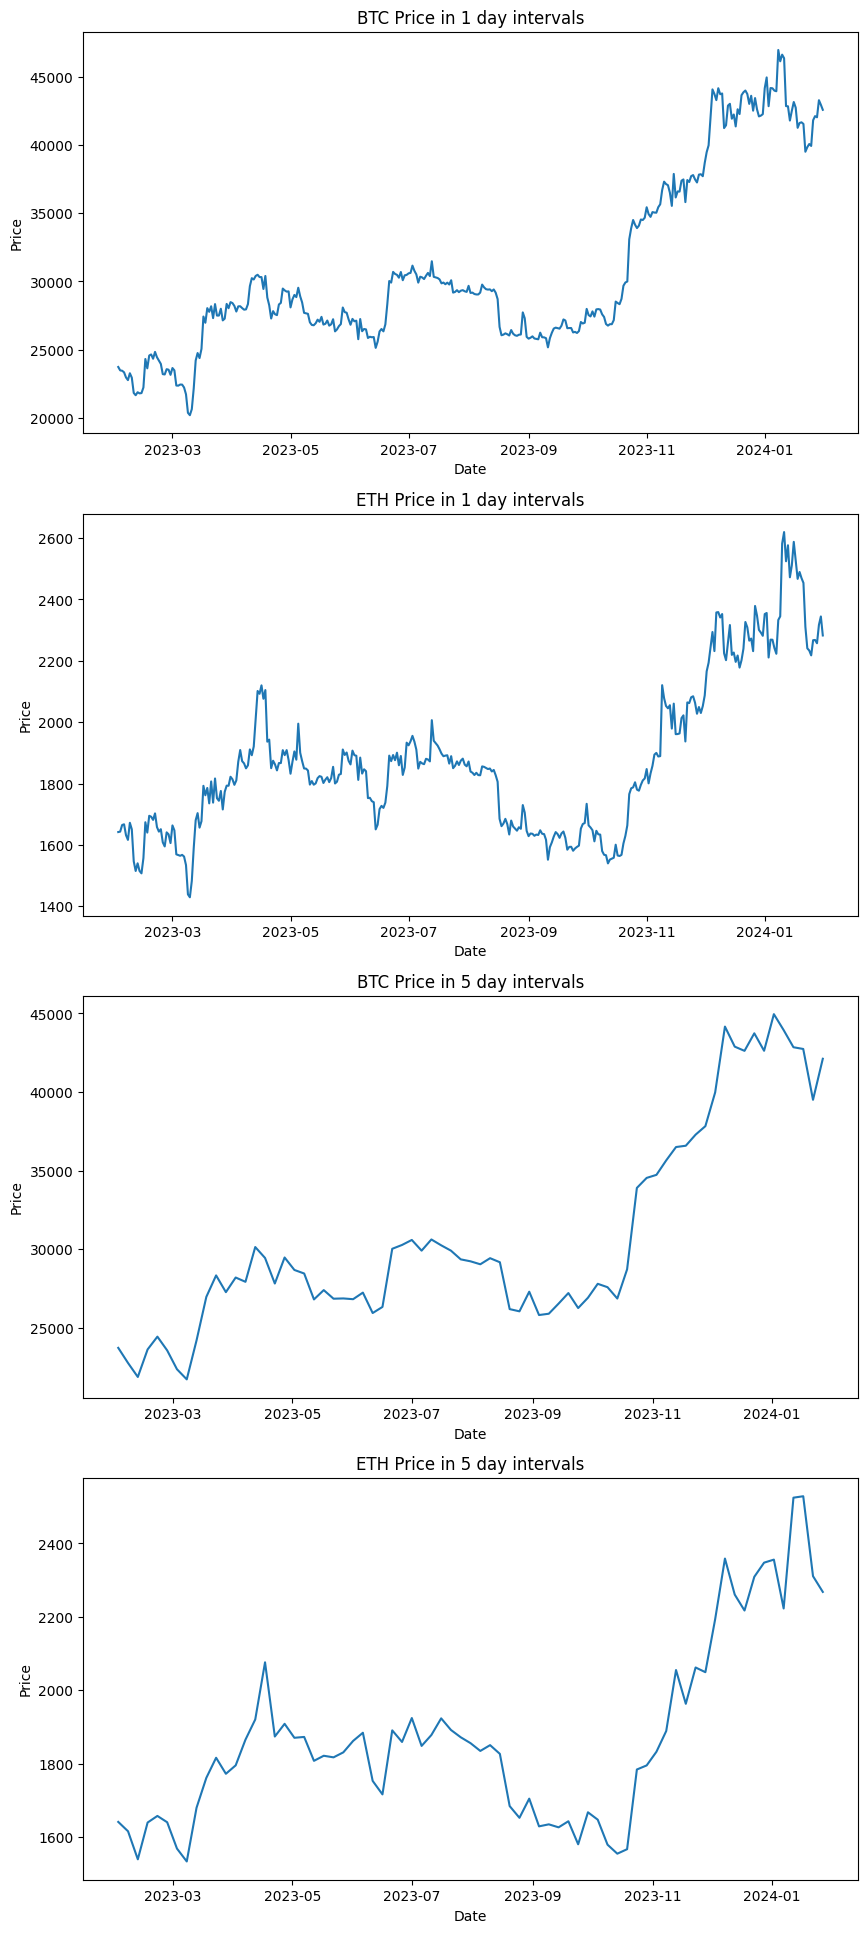

In [1647]:
plt.figure(figsize=(10,24))

plt.subplot(4,1,1)
plt.plot(BTC_1d.Close)
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("BTC Price in 1 day intervals")

plt.subplot(4,1,2)
plt.plot(ETH_1d.Close)
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("ETH Price in 1 day intervals")

plt.subplot(4,1,3)
plt.plot(BTC_5d.Close)
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("BTC Price in 5 day intervals")

plt.subplot(4,1,4)
plt.plot(ETH_5d.Close)
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("ETH Price in 5 day intervals")

plt.show()

Section 1

In [1648]:
from statistics import mean, stdev

In [1649]:
period = 20
correlation = 2

In [1650]:
def BollingerBand(stock):
    def SMA(series):
        return series.rolling(period).apply(mean)

    def STD(series):
        return series.rolling(period).apply(stdev)

    def UpperBound(series):
        std = STD(series)
        sma = SMA(series)
        return sma + std * correlation

    def LowerBound(series):
        std = STD(series)
        sma = SMA(series)
        return sma - std * correlation

    middle_bound = pd.Series(SMA(stock), name="middle_bound")
    upper_bound = pd.Series(UpperBound(stock), name="upper_bound")
    lower_bound = pd.Series(LowerBound(stock), name="lower_bound")
    bollinger_band = pd.concat([middle_bound, upper_bound, lower_bound], axis="columns")

    return bollinger_band

<Axes: xlabel='Date'>

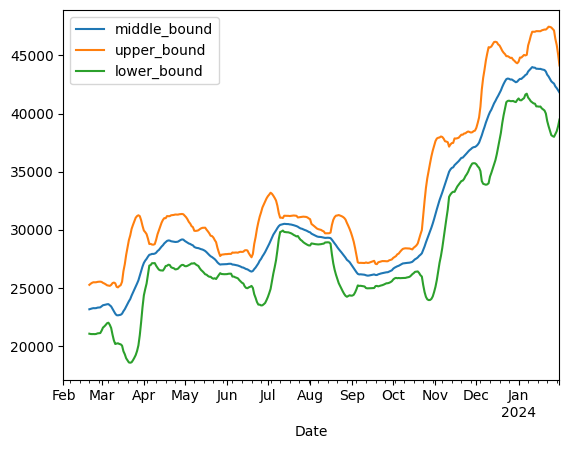

In [1651]:
# This is just for test.
BollingerBand(BTC_1d.Close).plot()

In [1652]:
def KeltnerChannel(stock, n=14):
    def SMA(series):
        return series.rolling(period).apply(mean)

    def return_max(series):
        return max(
            series["high_low_diff"],
            series["high_prevclose_diff"],
            series["low_prev_close_diff"],
        )

    def TR(series):
        high_low_diff = series.High - series.Low
        high_prevclose_diff = abs(series.High - series.Close.shift(periods=1))
        low_prev_close_diff = abs(series.Low - series.Close.shift(periods=1))
        TR = pd.concat(
            [high_low_diff, high_prevclose_diff, low_prev_close_diff],
            axis=1,
        )
        TR.columns = ["high_low_diff", "high_prevclose_diff", "low_prev_close_diff"]
        TR["TR"] = TR.apply(return_max, axis=1)
        return TR["TR"]

    def ATR(series, n):
        tr = TR(series)
        prev_atr = mean(tr[:14])
        atr = pd.Series(np.nan, index=series.index)
        for day in series.index[14:]:
            current_atr = (tr.loc[day] + (n - 1) * prev_atr) / n
            atr.loc[day] = current_atr
            prev_atr = current_atr

        return atr

    def UpperBound(sma, atr):
        return sma + atr * correlation

    def LowerBound(sma, atr):
        return sma - atr * correlation

    atr = ATR(stock, n)
    sma = SMA(stock.Close)
    upper_bound = pd.Series(UpperBound(sma, atr), name="upper_bound")
    lower_bound = pd.Series(LowerBound(sma, atr), name="lower_bound")
    keltner_channel = pd.concat([upper_bound, lower_bound], axis="columns")
    return keltner_channel

<Axes: xlabel='Date'>

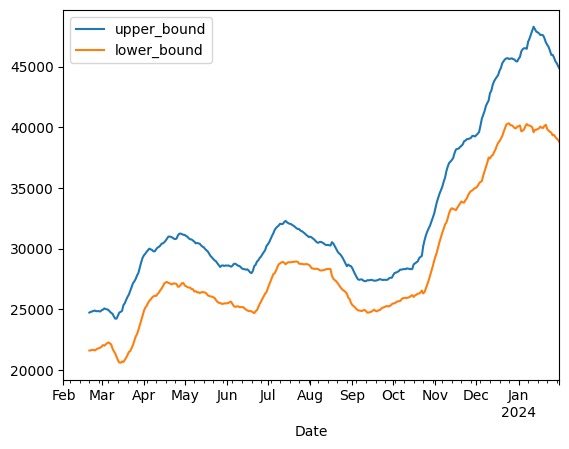

In [1653]:
# This is just for plotting.
KeltnerChannel(BTC_1d).plot()

In [1654]:
def RSI(series, n=14):
    dUp, dDown = series.copy().diff(), series.copy().diff()
    dUp[dUp < 0] = 0
    dDown[dDown > 0] = 0
    RolUp = dUp.rolling(n).mean()
    RolDown = dDown.rolling(n).mean().abs()
    RS = RolUp / RolDown
    return 100 - (100 / (1 + RS))

<Axes: xlabel='Date'>

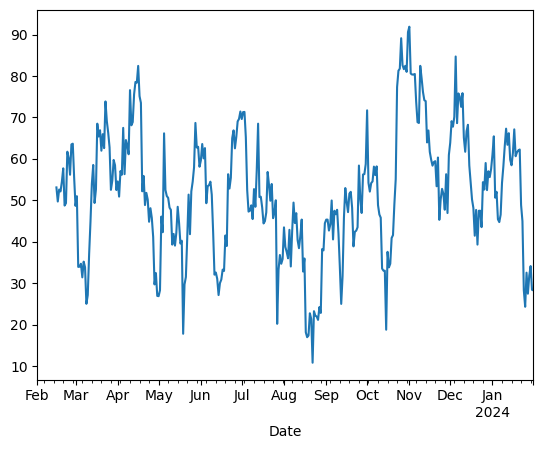

In [1655]:
# This is just for test.
RSI(ETH_1d.Close).plot()

In [1656]:
def backtest(stock, init_fund=1000, fund_rate=1):
    bollingerband_analysis = BollingerBand(stock.Close)
    keltnerchannel_analysis = KeltnerChannel(stock)
    rsi_analysis = RSI(stock.Close)

    oversold = 30
    overbought = 70

    current_share = 0
    current_fund = init_fund
    buy_holding = False
    sell_holding = False
    sell_price = None

    events_list = []
    fund_per_day = pd.Series(0, index=stock.index)
    for day in stock.index:
        stock_price = stock.loc[day].Open
        b_price = bollingerband_analysis.loc[day]
        k_price = keltnerchannel_analysis.loc[day]
        rsi_rate = rsi_analysis.loc[day]
        # Buy
        if (
            not buy_holding
            and stock_price <= b_price["lower_bound"]
            and stock_price <= k_price["lower_bound"]
            and rsi_rate <= oversold
        ):
            if sell_holding:
                current_fund += current_share * sell_price
                current_fund += (sell_price - stock_price) * current_share
                current_share = 0
                sell_holding = False
            events_list.append(("b", day))
            current_share += fund_rate * current_fund / stock_price
            current_fund -= current_share * stock_price
            buy_holding = True
        # Sell
        elif (
            not sell_holding
            and stock_price >= b_price.loc["upper_bound"]
            and stock_price >= k_price["upper_bound"]
            and rsi_rate >= overbought
        ):
            if buy_holding:
                current_fund += stock_price * current_share
                current_share = 0
                buy_holding = False
            events_list.append(("s", day))
            current_share += fund_rate * current_fund / stock_price
            current_fund -= current_share * stock_price
            sell_price = stock_price
            sell_holding = True

        fund_per_day.loc[day] = current_fund + current_share * stock_price

    return fund_per_day, events_list

In [1657]:
fund_rate = 1

C:\Users\Win\AppData\Local\Temp\ipykernel_15288\3083296190.py:55: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '991.2051366022225' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  fund_per_day.loc[day] = current_fund + current_share * stock_price
C:\Users\Win\AppData\Local\Temp\ipykernel_15288\3083296190.py:55: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1025.0254415123666' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  fund_per_day.loc[day] = current_fund + current_share * stock_price
C:\Users\Win\AppData\Local\Temp\ipykernel_15288\3083296190.py:55: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '993.2863709911904' has dtype incompatible with int64, please exp

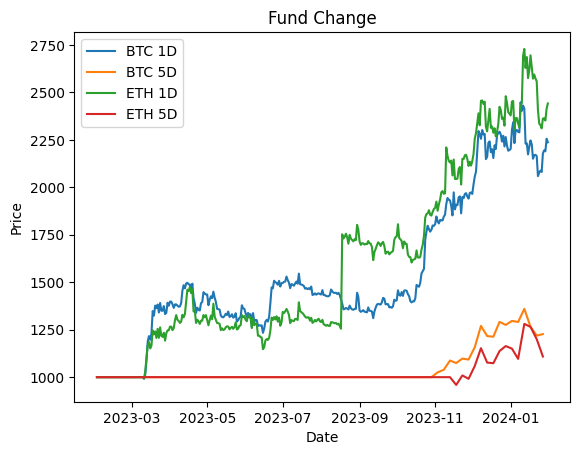

In [1658]:
BTC_1D_Result, BTC_1D_Events = backtest(BTC_1d, fund_rate=fund_rate)
BTC_5D_Result, BTC_5D_Events = backtest(BTC_5d, fund_rate=fund_rate)
ETH_1D_Result, ETH_1D_Events = backtest(ETH_1d, fund_rate=fund_rate)
ETH_5D_Result, ETH_5D_Events = backtest(ETH_5d, fund_rate=fund_rate)

plt.plot(BTC_1D_Result, label="BTC 1D")
plt.plot(BTC_5D_Result, label="BTC 5D")
plt.plot(ETH_1D_Result, label="ETH 1D")
plt.plot(ETH_5D_Result, label="ETH 5D")
plt.title("Fund Change")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

C:\Users\Win\AppData\Local\Temp\ipykernel_15288\1425625354.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\Win\AppData\Local\Temp\ipykernel_15288\1425625354.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\Win\AppData\Local\Temp\ipykernel_15288\1425625354.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\Win\AppData\Local\Temp\ipykernel_15288\1425625354.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend

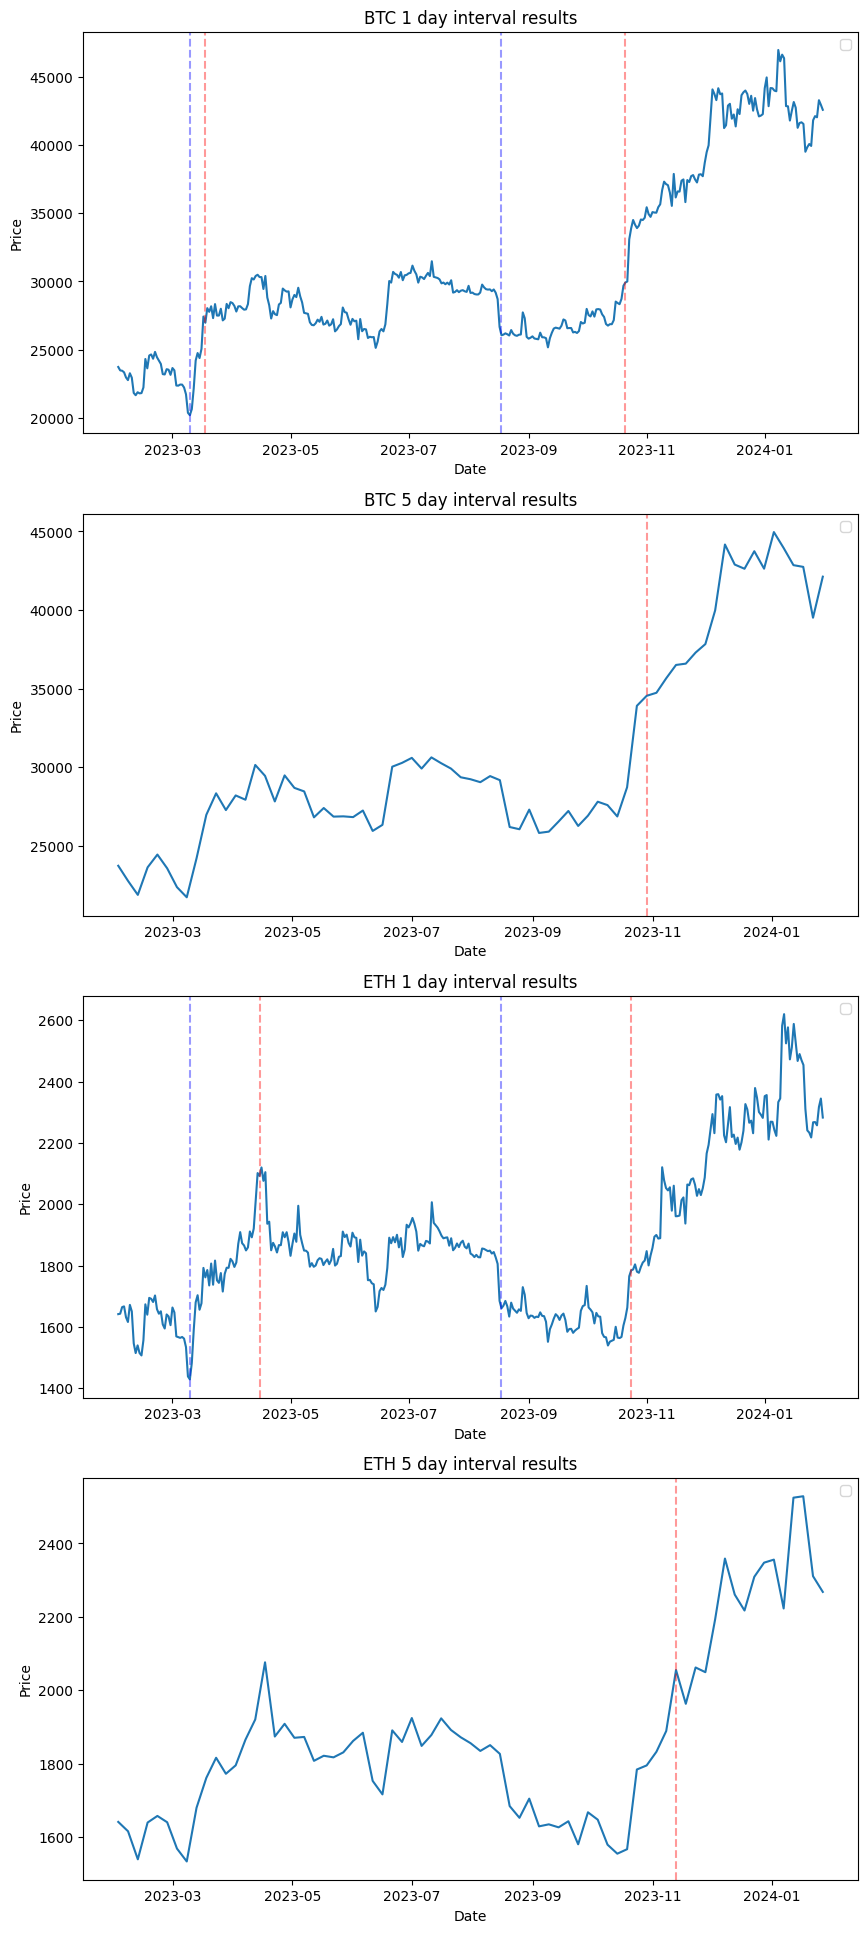

In [1659]:
# Plotting Strategy Backtest
plt.figure(figsize=(10, 24))

plt.subplot(4,1,1)
plt.plot(BTC_1d.Close)
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
for idx, event in enumerate(BTC_1D_Events):
    color = 'red' if event[0] == 's' else 'blue'
    plt.axvline(event[1], color=color, linestyle='--', alpha=0.4)
plt.title("BTC 1 day interval results")

plt.subplot(4,1,2)
plt.plot(BTC_5d.Close)
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
for idx, event in enumerate(BTC_5D_Events):
    color = 'red' if event[0] == 's' else 'blue'
    plt.axvline(event[1], color=color, linestyle='--', alpha=0.4)
plt.title("BTC 5 day interval results")

plt.subplot(4,1,3)
plt.plot(ETH_1d.Close)
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
for idx, event in enumerate(ETH_1D_Events):
    color = 'red' if event[0] == 's' else 'blue'
    plt.axvline(event[1], color=color, linestyle='--', alpha=0.4)
plt.title("ETH 1 day interval results")

plt.subplot(4,1,4)
plt.plot(ETH_5d.Close)
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
for idx, event in enumerate(ETH_5D_Events):
    color = 'red' if event[0] == 's' else 'blue'
    plt.axvline(event[1], color=color, linestyle='--', alpha=0.4)
plt.title("ETH 5 day interval results")
plt.show()

In [1660]:
def NetProfit(series, init_fund=1000):
    return series.iloc[-1] - init_fund


def SharpeRatio(series, risk_free_ratio=24):
    mean = series.pct_change().mean() * 365 - risk_free_ratio
    sigma = series.pct_change().std() * np.sqrt(365)
    return mean / sigma


def SortinoRatio(series, risk_free_ratio=24):
    stock = series.pct_change()
    mean = stock.mean() * 365 - risk_free_ratio
    std_neg = stock[stock < 0].std() * np.sqrt(365)
    return mean / std_neg


def MaxDrawDown(series):
    biggest_max = 1
    lowest_min = 1
    for day1 in range(len(series.index) - 1):
        for day2 in range(day1 + 1, len(series.index)):
            if series.iloc[day1] - series.iloc[day2] > biggest_max - lowest_min:
                biggest_max = series.iloc[day1]
                lowest_min = series.iloc[day2]
    return (lowest_min - biggest_max) / biggest_max * 100

In [1661]:
result = f"""BTC 1 day interval results are listed below
      \tNet Profit : {NetProfit(BTC_1D_Result):.2f}
      \tSharpe Ratio : {SharpeRatio(BTC_1D_Result):.2f}
      \tSortino Ratio : {SortinoRatio(BTC_1D_Result):.2f}
      \tMax Drawdown : {MaxDrawDown(BTC_1D_Result):.2f}
BTC 5 day interval results are listed below
\tNet Profit : {NetProfit(BTC_5D_Result):.2f}
\tSharpe Ratio : {SharpeRatio(BTC_5D_Result):.2f}
\tSortino Ratio : {SortinoRatio(BTC_5D_Result):.2f}
\tMax Drawdown : {MaxDrawDown(BTC_5D_Result):.2f}
ETH 1 day interval results are listed below
\tNet Profit : {NetProfit(ETH_1D_Result):.2f}
\tSharpe Ratio : {SharpeRatio(ETH_1D_Result):.2f}
\tSortino Ratio : {SortinoRatio(ETH_1D_Result):.2f}
\tMax Drawdown : {MaxDrawDown(ETH_1D_Result):.2f}
ETH 5 day interval results are listed below
\tNet Profit : {NetProfit(ETH_5D_Result):.2f}
\tSharpe Ratio : {SharpeRatio(ETH_5D_Result):.2f}
\tSortino Ratio : {SortinoRatio(ETH_5D_Result):.2f}
\tMax Drawdown : {MaxDrawDown(ETH_5D_Result):.2f}
"""
print(result)

BTC 1 day interval results are listed below
      	Net Profit : 1237.19
      	Sharpe Ratio : -56.54
      	Sortino Ratio : -88.59
      	Max Drawdown : -15.90
BTC 5 day interval results are listed below
	Net Profit : 226.65
	Sharpe Ratio : -57.01
	Sortino Ratio : -49.84
	Max Drawdown : -10.36
ETH 1 day interval results are listed below
	Net Profit : 1441.51
	Sharpe Ratio : -38.86
	Sortino Ratio : -80.76
	Max Drawdown : -15.34
ETH 5 day interval results are listed below
	Net Profit : 108.52
	Sharpe Ratio : -40.48
	Sortino Ratio : -46.78
	Max Drawdown : -13.43



Section 2

In [1662]:
def backtest(stock, init_fund=1000, fund_rate=1):
    bollinger_analysis = BollingerBand(stock.Close)

    current_fund = init_fund
    current_share = 0
    sell_holding = False
    sell_signal = False
    buy_holding = False
    buy_signal = False
    sell_price = None

    events_list = []
    fund_per_day = pd.Series(0, index=stock.index)
    for day in stock.index:
        b_lower_bound = bollinger_analysis.loc[day]["lower_bound"]
        b_upper_bound = bollinger_analysis.loc[day]["upper_bound"]

        if sell_signal and not sell_holding:
            sell_signal = False
            if buy_holding:
                buy_holding = False
                current_fund += current_share * stock.loc[day].Open
                current_share = 0
            sell_holding = True
            current_share += current_fund / stock.loc[day].Open
            current_fund -= current_share * stock.loc[day].Open
            sell_price = stock.loc[day].Open
            events_list.append(('s', day))

        if buy_signal and not buy_holding:
            buy_signal = False
            if sell_holding:
                sell_holding = False
                current_fund += current_share * sell_price
                current_fund += (sell_price - stock.loc[day].Open) * current_share
                current_share = 0
            buy_holding = True
            current_share += current_fund / stock.loc[day].Open
            current_fund -= current_share * stock.loc[day].Open
            events_list.append(('b', day))

        if stock.loc[day].Close > b_upper_bound:
            sell_signal = True
        else:
            sell_signal = False
        if stock.loc[day].Close < b_lower_bound:
            buy_signal = True
        else:
            buy_signal = False

        fund_per_day.loc[day] = current_fund + current_share * stock.loc[day].Close

    return fund_per_day, events_list

In [1663]:
fund_rate = 1
init_fund = 2000

In [1664]:
BTC_1D_Result, BTC_1d_Events = backtest(
    BTC_1d, init_fund=init_fund, fund_rate=fund_rate
)
BTC_5D_Result, BTC_5d_Events = backtest(
    BTC_5d, init_fund=init_fund, fund_rate=fund_rate
)
ETH_1D_Result, ETH_1d_Events = backtest(
    ETH_1d, init_fund=init_fund, fund_rate=fund_rate
)
ETH_5D_Result, ETH_5d_Events = backtest(
    ETH_5d, init_fund=init_fund, fund_rate=fund_rate
)

C:\Users\Win\AppData\Local\Temp\ipykernel_15288\1340331003.py:51: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1982.3481322470811' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  fund_per_day.loc[day] = current_fund + current_share * stock.loc[day].Close
C:\Users\Win\AppData\Local\Temp\ipykernel_15288\1340331003.py:51: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2026.3489387213917' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  fund_per_day.loc[day] = current_fund + current_share * stock.loc[day].Close
C:\Users\Win\AppData\Local\Temp\ipykernel_15288\1340331003.py:51: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1986.6523257507877' has dtype incompatible wi

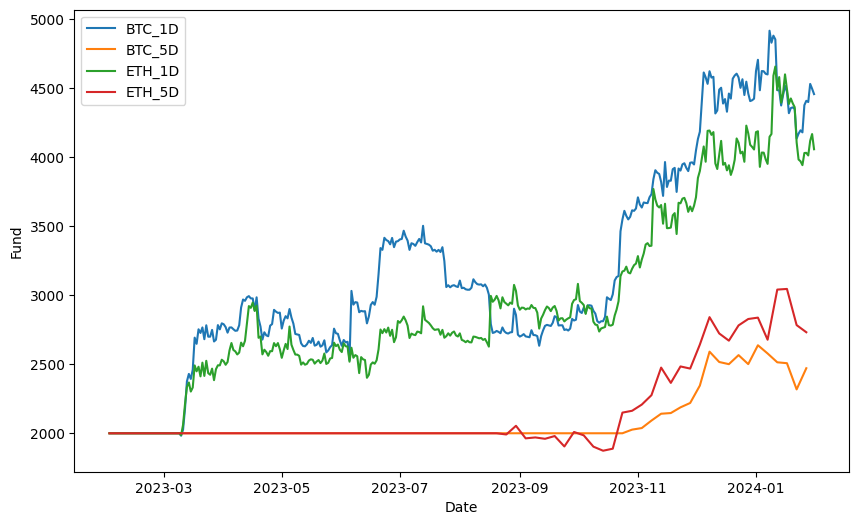

In [1665]:
# Plotting Strategy Backtest
plt.figure(figsize=(10, 6))
plt.plot(BTC_1D_Result, label="BTC_1D")
plt.plot(BTC_5D_Result, label="BTC_5D")
plt.plot(ETH_1D_Result, label="ETH_1D")
plt.plot(ETH_5D_Result, label="ETH_5D")
plt.xlabel("Date")
plt.ylabel("Fund")
plt.legend()
plt.show()

In [1666]:
result = f"""BTC 1 day interval results are listed below
      \tNet Profit : {NetProfit(BTC_1D_Result, init_fund=init_fund ):.2f}
      \tSharpe Ratio : {SharpeRatio(BTC_1D_Result):.2f}
      \tSortino Ratio : {SortinoRatio(BTC_1D_Result):.2f}
      \tMax Drawdown : {MaxDrawDown(BTC_1D_Result):.2f}
BTC 5 day interval results are listed below
\tNet Profit : {NetProfit(BTC_5D_Result, init_fund=init_fund ):.2f}
\tSharpe Ratio : {SharpeRatio(BTC_5D_Result):.2f}
\tSortino Ratio : {SortinoRatio(BTC_5D_Result):.2f}
\tMax Drawdown : {MaxDrawDown(BTC_5D_Result):.2f}
ETH 1 day interval results are listed below
\tNet Profit : {NetProfit(ETH_1D_Result, init_fund=init_fund ):.2f}
\tSharpe Ratio : {SharpeRatio(ETH_1D_Result):.2f}
\tSortino Ratio : {SortinoRatio(ETH_1D_Result):.2f}
\tMax Drawdown : {MaxDrawDown(ETH_1D_Result):.2f}
ETH 5 day interval results are listed below
\tNet Profit : {NetProfit(ETH_5D_Result, init_fund=init_fund ):.2f}
\tSharpe Ratio : {SharpeRatio(ETH_5D_Result):.2f}
\tSortino Ratio : {SortinoRatio(ETH_5D_Result):.2f}
\tMax Drawdown : {MaxDrawDown(ETH_5D_Result):.2f}
"""
print(result)

BTC 1 day interval results are listed below
      	Net Profit : 2457.39
      	Sharpe Ratio : -50.26
      	Sortino Ratio : -82.36
      	Max Drawdown : -24.81
BTC 5 day interval results are listed below
	Net Profit : 471.15
	Sharpe Ratio : -56.36
	Sortino Ratio : -50.03
	Max Drawdown : -12.12
ETH 1 day interval results are listed below
	Net Profit : 2057.93
	Sharpe Ratio : -50.08
	Sortino Ratio : -81.96
	Max Drawdown : -15.34
ETH 5 day interval results are listed below
	Net Profit : 731.95
	Sharpe Ratio : -33.60
	Sortino Ratio : -49.40
	Max Drawdown : -10.30



C:\Users\Win\AppData\Local\Temp\ipykernel_15288\1678461389.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\Win\AppData\Local\Temp\ipykernel_15288\1678461389.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\Win\AppData\Local\Temp\ipykernel_15288\1678461389.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\Win\AppData\Local\Temp\ipykernel_15288\1678461389.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend

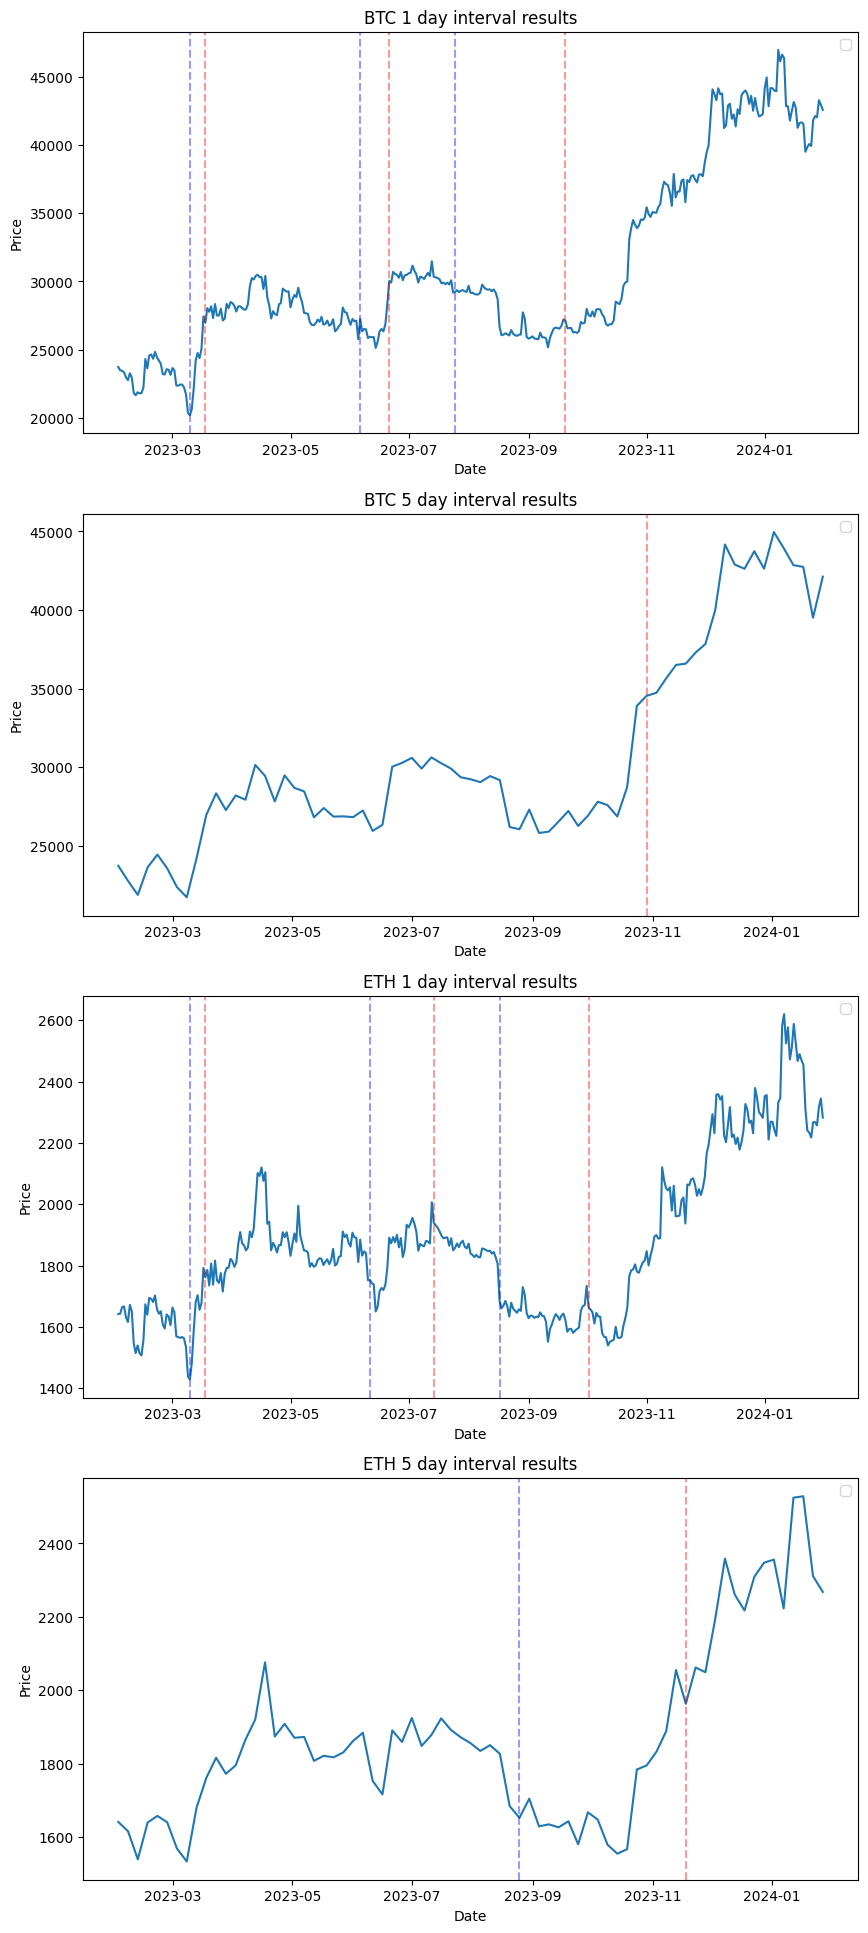

In [1667]:
# Plotting Strategy Backtest
plt.figure(figsize=(10, 24))

plt.subplot(4,1,1)
plt.plot(BTC_1d.Close)
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
for idx, event in enumerate(BTC_1d_Events):
    color = 'red' if event[0] == 's' else 'blue'
    plt.axvline(event[1], color=color, linestyle='--', alpha=0.4)
plt.title("BTC 1 day interval results")

plt.subplot(4,1,2)
plt.plot(BTC_5d.Close)
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
for idx, event in enumerate(BTC_5d_Events):
    color = 'red' if event[0] == 's' else 'blue'
    plt.axvline(event[1], color=color, linestyle='--', alpha=0.4)
plt.title("BTC 5 day interval results")

plt.subplot(4,1,3)
plt.plot(ETH_1d.Close)
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
for idx, event in enumerate(ETH_1d_Events):
    color = 'red' if event[0] == 's' else 'blue'
    plt.axvline(event[1], color=color, linestyle='--', alpha=0.4)
plt.title("ETH 1 day interval results")

plt.subplot(4,1,4)
plt.plot(ETH_5d.Close)
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
for idx, event in enumerate(ETH_5d_Events):
    color = 'red' if event[0] == 's' else 'blue'
    plt.axvline(event[1], color=color, linestyle='--', alpha=0.4)
plt.title("ETH 5 day interval results")
plt.show()